# Prompt-Based Picking with ProPicker

In this notebook, we pick ribosomes in a single (defocus-only) tomogram contained in the EMPIAR-10988 dataset. To download the relevant parts of the dataset, you can use the `../download_tutorial_data.sh` script:

```bash
bash tutorial_data.sh
```

This will create a folder called `empiar` which contains tomograms from the EMPIAR-10988 dataset and annotations.

**Note:** The dataset is large >100GB. Make sure you have enough disk space before downloading.

In [12]:
import torch

from matplotlib import pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter

from propicker.clustering_and_picking import get_cluster_centroids_df
from propicker.evaluation import evaluate_picks, get_best_case_cluster_based_picking_performance
from propicker.data.preparation_functions.prepare_empiar10988 import read_empiar10988_coords, empiar10988_ts_to_slice_of_interest
from propicker.data.utils import draw_balls
from propicker.paths import PROPICKER_MODEL_FILE, TOMOTWIN_MODEL_FILE
from propicker.inference import get_pred_locmap_dict
from propicker.model import ProPicker
from propicker.utils.mrctools import *

# sometimes, jupyer notebooks have trouble reading the environment variables, so you can also set the paths here directly
PROPICKER_MODEL_FILE = "/workspaces/ProPicker/propicker.ckpt" if PROPICKER_MODEL_FILE is None else PROPICKER_MODEL_FILE
TOMOTWIN_MODEL_FILE = "/workspaces/ProPicker/tomotwin.pth" if TOMOTWIN_MODEL_FILE is None else TOMOTWIN_MODEL_FILE

## Step 0: Load Data


/opt/conda/envs/ppicker/lib/python3.11/site-packages/propicker/utils/mrctools.py:8: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /opt/conda/conda-bld/pytorch_1720538437738/work/torch/csrc/utils/tensor_numpy.cpp:206.)
  data = torch.from_numpy(mrc.data)


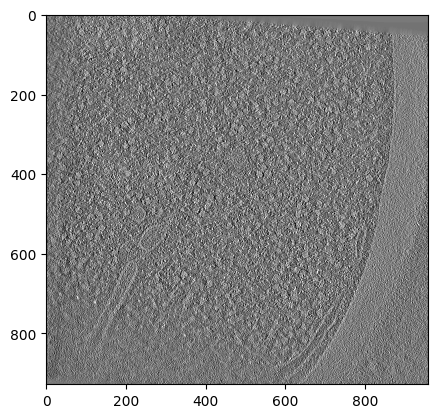

In [3]:
# path to the empiar10988 dataset, assuming 'empiar' folder is in the parent directory
EMPIAR10988_BASE_DIR = "../empiar/10988/DEF"
# we use this tomogram as calibration tomogram to select a prompt and hyperparameters
ts_id = "TS_030"

tomo_file = f"{EMPIAR10988_BASE_DIR}/tomograms/{ts_id}.rec"
ribo_coord_file = f"{EMPIAR10988_BASE_DIR}/particle_lists/{ts_id}_cyto_ribosomes.csv"

# tomograms contain large emtpy regions, so we only consider the interesting part
slice_of_interest = empiar10988_ts_to_slice_of_interest[ts_id]
tomo = -1 * load_mrc_data(tomo_file).float()
tomo = tomo[slice_of_interest].clone()


coords = read_empiar10988_coords(ribo_coord_file)
coords.Z -= slice_of_interest.start

plt.imshow(tomo[100], vmin=-2*tomo.std(), vmax=2*tomo.std(), cmap="gray")

## Step 1: Picking a Single Ribosome as Prompt

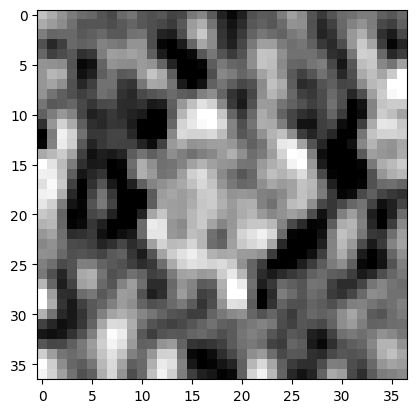

In [4]:
# extract all ribosomes as subtomos of shape (37, 37, 37); this shape is the one needed for the TomoTwin prompt encoder
all_ribo_subtomos = []
for coord in coords[["X", "Y", "Z"]].values.astype(int):
    x, y, z = coord
    subtomo = tomo[
        z-18:z+19,
        y-18:y+19,
        x-18:x+19
    ]
    # some ribosomes are at the edge of the tomogram, so we skip them
    if not subtomo.shape == (37, 37, 37):
        continue
    all_ribo_subtomos.append(subtomo)
    
# you can choose any of the ribo subtomos as prompt, we used the 300th one in our experiment in the paper
prompt = all_ribo_subtomos[300]
prompt_subtomos_dict = {"cyto_ribosome": prompt}

# inspect prompt
prompt_filt = gaussian_filter(prompt, 1)
plt.imshow(prompt_filt[18], vmin=-2*prompt_filt.std(), vmax=2*prompt_filt.std(), cmap="gray")

## Step 2: Applying the Conditional ProPicker Segmentation Model

/opt/conda/envs/ppicker/lib/python3.11/site-packages/lightning_lite/utilities/cloud_io.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(f, map_location

Model config:
{'identifier': 'SiameseNet', 'network_config': {'output_channels': 32, 'dropout': 0.2, 'repeat_layers': 0, 'norm_name': 'GroupNorm', 'norm_kwargs': {'num_groups': 64, 'num_channels': 1024}, 'gem_pooling_p': 0}, 'train_config': {'loss': 'TripletLoss', 'tl_margin': 0.539, 'miner': True, 'miner_margin': 0.734, 'learning_rate': 5.945e-05, 'optimizer': 'Adam', 'weight_decay': 0, 'batchsize': 35, 'patience': 50, 'aug_train_shift_distance': 2}, 'distance': 'COSINE'}
Successfully loaded model weights


Inference (1 prompts):   0%|          | 0/381 [00:00<?, ?it/s]/opt/conda/envs/ppicker/lib/python3.11/site-packages/torch/functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1720538437738/work/aten/src/ATen/native/TensorShape.cpp:3609.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Inference (1 prompts): 100%|██████████| 381/381 [06:54<00:00,  1.09s/it]


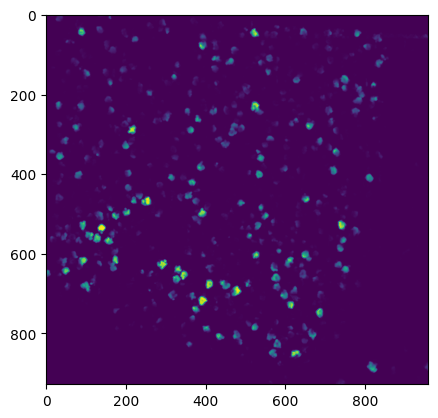

In [5]:
device = "cuda:0"

model = ProPicker.load_from_checkpoint(PROPICKER_MODEL_FILE, map_location="cpu").to(device)
model = model.to(device).eval()
model.freeze()
pred_locmap_dict = get_pred_locmap_dict(
    model, 
    tomo, 
    prompt_subtomos_dict=prompt_subtomos_dict, 
    #prompt_embeds_dict=prompt_embeds_dict,
    tomotwin_model_file=TOMOTWIN_MODEL_FILE,  # tomotwin encoder is used to embe^d prompts in prompt_subtomos_dict
    subtomo_size=64,  # propicker processes the tomogram in subtomos of this size 
    subtomo_overlap=32,  # overlap of the subtomos, you can also reduce this to speed up inference, 16 should also work fine
    batch_size=16,
    mean_pool_locmaps=0,  # you can use this to blur the model outputs, which can help with clustering and may remove some false positives; for crowded tomos such as EMPIAR10988, this is not recommended as it may lead to overlapping particle clusters
)

plt.imshow(pred_locmap_dict["cyto_ribosome"][100])

## Step 3: Cluster-Based Picking

Apply thresholding and clustering to the ProPicker segmentation map to pick ribosomes. By tuning the hyperparameters for cluster-based picking, i.e. `binarization_threshold`, `min_cluster_size` and `max_cluster_size`, we can trade off precision and recall:
- `binarization_threshold`: The threshold for binarizing the ProPicker segmentation map. A smaller threshold will result in large clusters and higher recall, whereas a larger threshold will result in smaller clusters and higher precision. You can tune this such that the binarized locmap segments the particles well.
- `min_cluster_size`, `max_cluster_size`: We discard clusters with fewer than `min_cluster_size` or more than `max_cluster_size` particles. These parameters can be used to filter out false positives (improve precision), or to enforce a certain size distribution of the picked particles. If you choose a large `binarization_threshold`, you typically have to decrease `min_cluster_size` and `max_cluster_size` to pick enough particles.

In [6]:
binarization_thresh = 0.1  
binary_locmap = pred_locmap_dict["cyto_ribosome"] > binarization_thresh
# apply clustering to thresholded locmap
cluster_centroids = get_cluster_centroids_df(binary_locmap)
print(f"Number of clusters: {len(cluster_centroids)}")
print(cluster_centroids.head(5))

Number of clusters: 1937
       X     Y     Z   size
0  700.0  47.0   9.0   4775
1  797.0  58.0  23.0  15787
2  883.0  52.0   4.0   1124
3  935.0  52.0   3.0    561
4  866.0  53.0   4.0   1159


In [7]:
# you can choose the cluster sizes based on particle sizes or using statistics of the cluster sizes, here we use the former and choose the cluster sizes based on the volume of a sphere with diameter 24 voxels which is approximately the size of a ribosome
diameter = 24  # in voxels
ball_volume = 4/3 * torch.pi * (diameter/2)**3  
min_cluster_size = 0.1 * ball_volume  
max_cluster_size = 1.0 * ball_volume 
# discard small and large clusters (cluster size is in voxels)
cluster_centroids_filt = cluster_centroids[
    (min_cluster_size <= cluster_centroids["size"]) & (cluster_centroids["size"] <= max_cluster_size)
].copy()
print(f"Number of clusters: {len(cluster_centroids_filt)}")
print(cluster_centroids_filt.head(5))

Number of clusters: 918
       X      Y     Z  size
0  700.0   47.0   9.0  4775
2  883.0   52.0   4.0  1124
4  866.0   53.0   4.0  1159
8  945.0  759.0  14.0  3442
9  564.0   38.0  15.0  2306


Drawing balls: 100%|██████████| 918/918 [00:49<00:00, 18.42it/s]


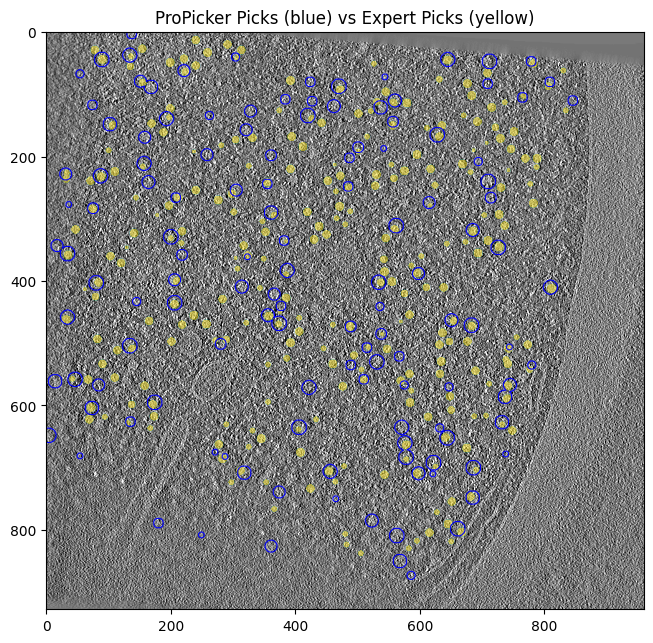

In [8]:
# draw the picked particles as balls
picks = draw_balls(
    positions=cluster_centroids_filt,
    shape=tomo.shape,
    radius=diameter//2,
    device=device,
)

# expert picks contained in the dataset
expert_picks = load_mrc_data(f"{EMPIAR10988_BASE_DIR}/labels/{ts_id}_cyto_ribosomes.mrc")[slice_of_interest].bool()


fig, ax = plt.subplots(1, 1, figsize=(15, 7.5))
ax.set_title("ProPicker Picks (blue) vs Expert Picks (yellow)")
ax.imshow(tomo[100], vmin=-2*tomo.std(), vmax=2*tomo.std(), cmap="gray")
ax.contour(picks[100].cpu(), colors="blue", levels=[0.5], linewidths=0.75)
ax.imshow(tomo[100], vmin=-2*tomo.std(), vmax=2*tomo.std(), cmap="gray")
ax.imshow(expert_picks[100], alpha=0.5*expert_picks[100])

### Metric-Based Evaluation of Picks

Computing picking metrics like the F1 score or Precision requires a true-positive criterion.
We use the same one as the authors of TomoTwin, that is, a pick is considered a true positive if a bounding box around is has an intersection-over-union (IoU) of at least 0.6 with a bounding box around and expert pick. 
The bounding box size should be chosen according to the particle size. For the ribosomes, we use a bounding box of 27x27x27 voxels. This true-positive criterion (which we used throughout our paper for consistency) is much stricter than the one used in the [DeePiCt paper](https://www.nature.com/articles/s41592-022-01746-2), in which the the EMPIAR-10988 dataset was proposed, so we get lower F1 scores.

In [9]:
bbox_size = 27  
coords["height"] = coords["width"] = coords["depth"] = bbox_size
cluster_centroids_filt["height"] = cluster_centroids_filt["width"] = cluster_centroids_filt["depth"] = bbox_size

In [10]:
# add class information to the picks so they can be matched with the corresponding expert picks
cluster_centroids_filt["class"] = "cyto_ribosome"

evaluate_picks(
    pred_positions=cluster_centroids_filt,
    gt_positions=coords,
    iou_thresh=0.6,  # a prediction is considered a true positive if the IoU is above this threshold
)

{'cyto_ribosome': {'F1': 0.2699784017278618,
  'Recall': 0.17966223499820339,
  'Precision': 0.5428881650380022,
  'TruePositiveRate': 0.17966223499820339,
  'TP': 500,
  'FP': 421,
  'FN': 2283}}

If you have a tomogram with expert picks, you can calibrate the binarization and size thresholds used for cluster-based picking. You can then apply the same parameters to other tomograms using the same procedure and prompt described in this notebook.

In [ ]:
best_case_results = get_best_case_cluster_based_picking_performance(
    pred_locmap_dict=pred_locmap_dict,
    optimize_thresh=True, # whether to optimize the binarization threshold
    n_thresh_steps=10,  # how many binarization thresholds to try between 0 and the max value in the locmap
    n_size_steps=5,  # how many min and max cluster sizes to try for each binarization threshold
    gt_positions=coords,
    metric="F1",  # you can optimize for "F1", "Precision" or "Recall"
    num_workers=0,
    # a predicted coordinate is a true positive if the IoU between a bbox-sized cube around it with any bbox-sized cube around a ground truth position is above this threshold 
    iou_thresh=0.6,  # 0.6 is pretty strict
)["cyto_ribosome"]
print(f"F1: {best_case_results['F1']:.4f}, Precision: {best_case_results['Precision']:.4f}, Recall: {best_case_results['Recall']:.4f}")       

Running evaluation with 1 workers
Optimizing threshold for cyto_ribosome between 3.5694539771841116e-12 and 0.9796692728996277


cyto_ribosome (Best F1: 0.30): 100%|██████████| 250/250 [03:58<00:00,  1.05it/s]

F1: 0.3017, Precision: 0.5250, Recall: 0.2116


# Conclusion

Prompt-based picking with ProPicker out-of-the-box gives decent results for picking ribosomes in the EMPIAR-10988 dataset. Precision and recall can be tuned by adjusting the binarization threshold and cluster size thresholds.

For best performance with ProPicker, we recommend fine-tuning the model on labeled data, which the out-of-the-box ProPicker can help you produce. A tutorial on fine-tuning can be found in the second tutorial notebook.